# imports and def

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import colormaps as cmaps

In [2]:
def reg_map(
    ds_to_plt,
    dots,
    bounds=[20, -180, 30, -30],
    name="figure",
    color=cmaps.posneg_1,
    lcolor=["magenta", "cyan"],
    lev=np.arange(-1.5, 1.5, 0.15),
):
    fig, ax = plt.subplots(1, 1, subplot_kw={"projection": ccrs.PlateCarree()})
    fig.subplots_adjust(hspace=0, wspace=0, top=0.925, left=0.1)
    cbar_ax = fig.add_axes([0, 0, 0.1, 0.1])
    cdat, clon = cutil.add_cyclic_point(ds_to_plt, ds_to_plt.lon)
    cdot, cdot_lon = cutil.add_cyclic_point(dots, dots.lon)

    ax.set_title(name)
    lat_ticks = np.arange(bounds[3], bounds[2] + 1, 15)
    lon_ticks = np.arange(bounds[1], bounds[0], 60)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # local function because it modifies local objects
    def resize_colobar(event):
        plt.draw()
        posn = ax.get_position()
        cbar_ax.set_position([posn.x0 + posn.width + 0.01, posn.y0, 0.04, posn.height])

    ax.set_extent(bounds, ccrs.PlateCarree())

    ds_plot = ax.contourf(
        clon,
        ds_to_plt.lat,
        cdat,
        levels=lev,
        # levels=40,
        transform=ccrs.PlateCarree(),
        cmap=color,
        extend="both",
    )

    dot_plot = ax.contourf(
        cdot_lon,
        dots.lat,
        cdot,
        transform=ccrs.PlateCarree(),
        linestyles="-",
        hatches=["..", ""],
        levels=[0, 0.05],
        colors="None",  # lcolor,
        alpha=0.1,
    )

    fig.canvas.mpl_connect("resize_event", resize_colobar)
    ax.add_feature(cf.LAND)
    ax.coastlines()
    plt.colorbar(ds_plot, cax=cbar_ax)
    resize_colobar(None)
    plt.savefig(name, dpi=300, bbox_inches="tight")
    plt.show()

# Import data

In [3]:
rCANI_JJAprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_precip_JJA.nc')
rCANI_SONprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_precip_SON.nc')
rEANI_JJAprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_precip_JJA.nc')
rEANI_SONprecip_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_precip_SON.nc')

rCANI_JJA_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_SSTA_JJA.nc')
rCANI_SON_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/CANI_SSTA_SON.nc')
rEANI_JJA_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_SSTA_JJA.nc')
rEANI_SON_SSTA_r = xr.open_dataset('/glade/u/home/acruz/ATLN_HG/Results/Reanalysis/EANI_SSTA_SON.nc')

new_dims = {'longitude': 'lon', 'latitude': 'lat'}

rCANI_JJA_SSTA_r = rCANI_JJA_SSTA_r.rename(new_dims)
rCANI_SON_SSTA_r = rCANI_SON_SSTA_r.rename(new_dims)
rEANI_JJA_SSTA_r = rEANI_JJA_SSTA_r.rename(new_dims)
rEANI_SON_SSTA_r = rEANI_SON_SSTA_r.rename(new_dims)

rCANI_JJA_SSTA_r = rCANI_JJA_SSTA_r.sortby(rCANI_JJA_SSTA_r.lat)
rCANI_SON_SSTA_r = rCANI_SON_SSTA_r.sortby(rCANI_SON_SSTA_r.lat)
rEANI_JJA_SSTA_r = rEANI_JJA_SSTA_r.sortby(rCANI_JJA_SSTA_r.lat)
rEANI_SON_SSTA_r = rEANI_SON_SSTA_r.sortby(rEANI_SON_SSTA_r.lat)

# Mask by pvalue

In [4]:
rCANI_JJAprecip_slope_sig = rCANI_JJAprecip_r['slope'].where(rCANI_JJAprecip_r['pvalue'] <= 0.05)
rCANI_SONprecip_slope_sig = rCANI_SONprecip_r['slope'].where(rCANI_SONprecip_r['pvalue'] <= 0.05)
rEANI_JJAprecip_slope_sig = rEANI_JJAprecip_r['slope'].where(rEANI_JJAprecip_r['pvalue'] <= 0.05)
rEANI_SONprecip_slope_sig = rEANI_SONprecip_r['slope'].where(rEANI_SONprecip_r['pvalue'] <= 0.05)

rCANI_JJA_SSTA_slope_sig = rCANI_JJA_SSTA_r['slope'].where(rCANI_JJA_SSTA_r['pvalue'] <= 0.05)
rCANI_SON_SSTA_slope_sig = rCANI_SON_SSTA_r['slope'].where(rCANI_SON_SSTA_r['pvalue'] <= 0.05)
rEANI_JJA_SSTA_slope_sig = rEANI_JJA_SSTA_r['slope'].where(rEANI_JJA_SSTA_r['pvalue'] <= 0.05)
rEANI_SON_SSTA_slope_sig = rEANI_SON_SSTA_r['slope'].where(rEANI_SON_SSTA_r['pvalue'] <= 0.05)

# Plots

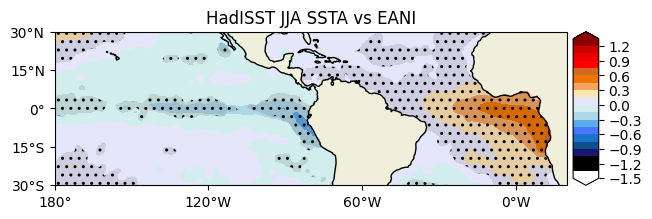

In [8]:
reg_map(rEANI_JJA_SSTA_r['slope'], rEANI_JJA_SSTA_r['pvalue'],
        name='HadISST JJA SSTA vs EANI')

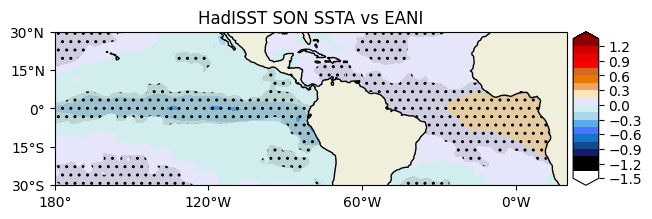

In [9]:
reg_map(rEANI_SON_SSTA_r['slope'], rEANI_SON_SSTA_r['pvalue'],
        name='HadISST SON SSTA vs EANI')

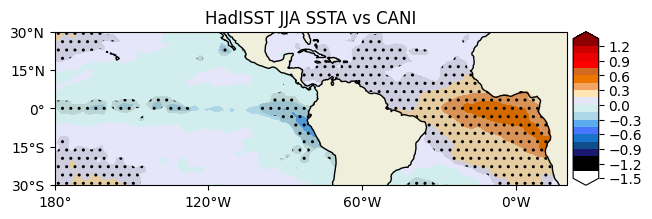

In [10]:
reg_map(rCANI_JJA_SSTA_r['slope'], rCANI_JJA_SSTA_r['pvalue'],
        name='HadISST JJA SSTA vs CANI')

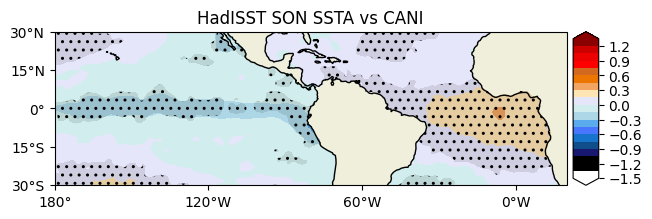

In [11]:
reg_map(rCANI_SON_SSTA_r['slope'], rCANI_SON_SSTA_r['pvalue'],
        name='HadISST SON SSTA vs CANI')

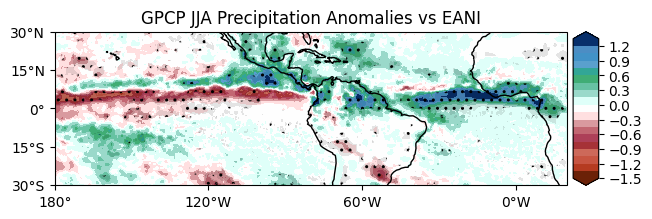

In [12]:
reg_map(rEANI_JJAprecip_r['slope'], rEANI_JJAprecip_r['pvalue'],
        name='GPCP JJA Precipitation Anomalies vs EANI',
        color=cmaps.precip4_diff_19lev)

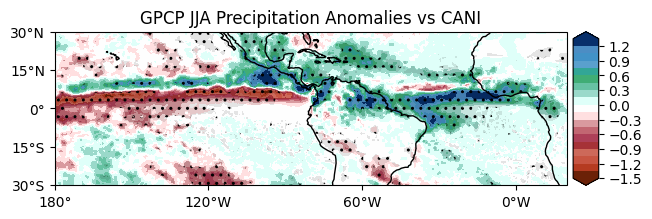

In [16]:
reg_map(rCANI_JJAprecip_r['slope'], rCANI_JJAprecip_r['pvalue'],
        name='GPCP JJA Precipitation Anomalies vs CANI',
        color=cmaps.precip4_diff_19lev)

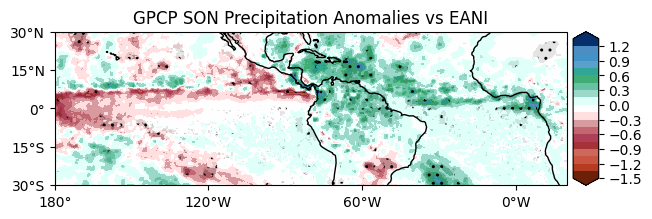

In [13]:
reg_map(rEANI_SONprecip_r['slope'], rEANI_SONprecip_r['pvalue'],
        name='GPCP SON Precipitation Anomalies vs EANI',
        color=cmaps.precip4_diff_19lev)

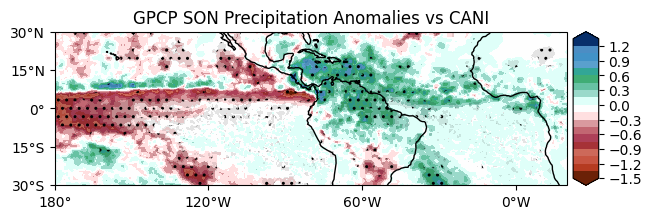

In [15]:
reg_map(rCANI_SONprecip_r['slope'], rCANI_SONprecip_r['pvalue'],
        name='GPCP SON Precipitation Anomalies vs CANI',
        color=cmaps.precip4_diff_19lev)